<a href="https://colab.research.google.com/github/ruyoliv/DataCom/blob/main/LineCodes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Códigos de linha

### Os códigos de linha são necessários na transmissão digital para converter dados binários brutos (0s e 1s) em sinais físicos (pulsos de tensão ou luz) adequados para um meio de transmissão específico. Eles permitem funções essenciais como a sincronização do receptor, a eliminação da componente DC, a detecção de erros e a eficiência de largura de banda, garantindo uma transferência de dados confiável.

LINE CODING SCHEMES VISUALIZATION

Enter a binary sequence (default: 1 0 1 1 0 0 1 0):
Binary bits (space-separated): 1 1 0 1 1 0 1 1

Using bits: [1, 1, 0, 1, 1, 0, 1, 1]


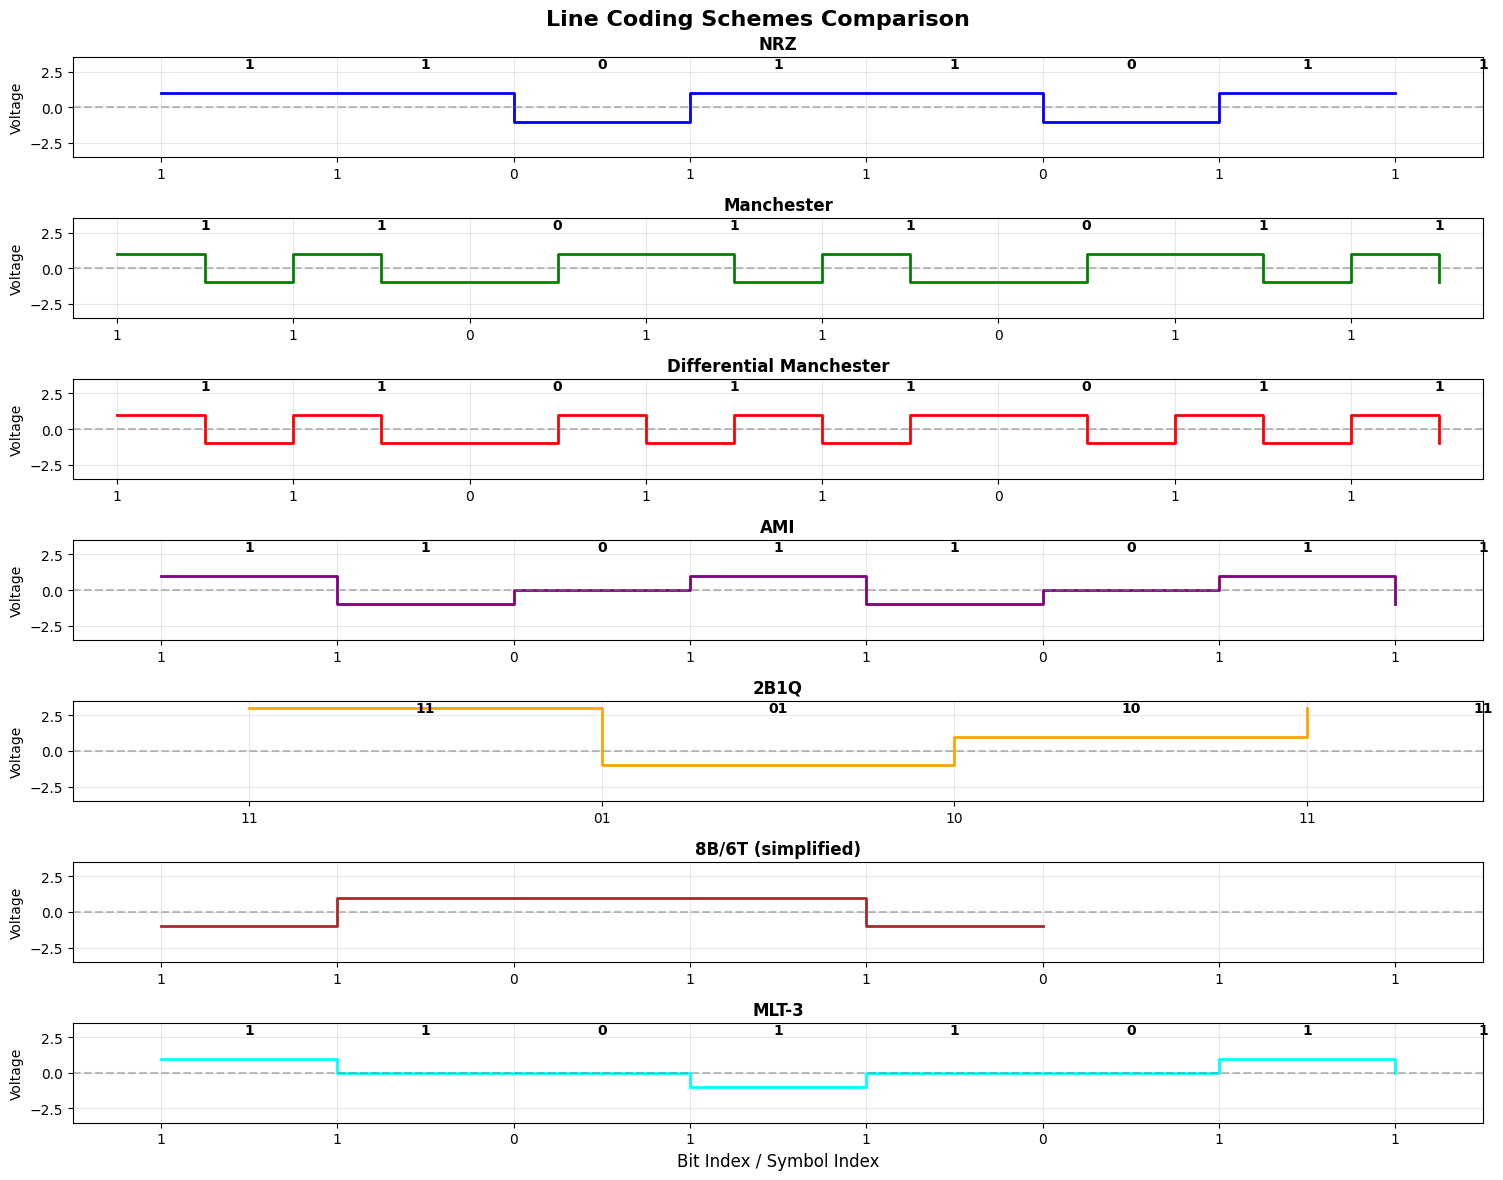

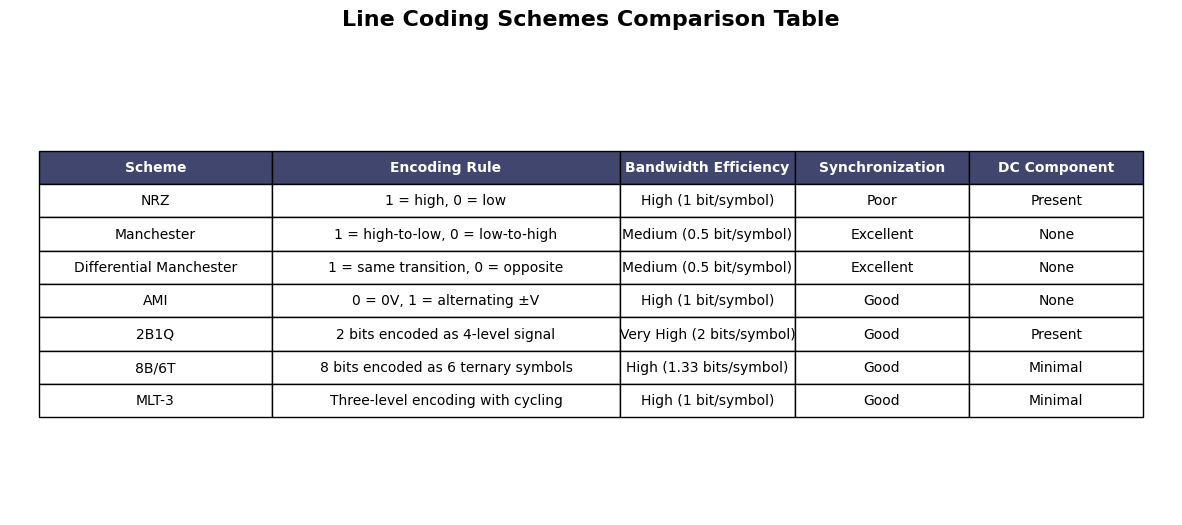


EXPLANATION OF EACH SCHEME:

NRZ (Non-Return-to-Zero):
  Simple encoding where 1 is represented by high voltage and 0 by low voltage. Easy to implement but lacks synchronization and has DC component.

Manchester:
  Each bit has a transition in the middle: 1 is high-to-low, 0 is low-to-high. Provides excellent synchronization and no DC component.

Differential Manchester:
  Similar to Manchester but uses transitions relative to previous bit. 1 means same transition as previous, 0 means opposite.

AMI (Alternate Mark Inversion):
  Three-level encoding where 0 is zero voltage and 1 alternates between +V and -V. No DC component and good error detection.

2B1Q (2 Binary 1 Quaternary):
  Groups 2 bits into one of four voltage levels. High bandwidth efficiency but susceptible to noise.

8B/6T:
  Groups 8 bits into 6 ternary symbols. Used in 100BASE-T4 Ethernet. Good balance of efficiency and DC balance.

MLT-3 (Multi-Level Transmit - 3 levels):
  Three-level encoding that cycles through stat

In [ ]:
# @title Line Coding Schemes Visualization
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Function to generate NRZ (Non-Return-to-Zero) encoding
def nrz_encode(bits):
    signal = []
    for bit in bits:
        signal.append(1 if bit == 1 else -1)
    return signal

# Function to generate Manchester encoding
def manchester_encode(bits):
    signal = []
    for bit in bits:
        if bit == 1:
            signal.extend([1, -1])  # 1: high-to-low
        else:
            signal.extend([-1, 1])  # 0: low-to-high
    return signal

# Function to generate Differential Manchester encoding
def diff_manchester_encode(bits, initial_state=1):
    signal = []
    last_bit = initial_state

    for bit in bits:
        if bit == 1:
            # Same transition as previous
            signal.extend([last_bit, -last_bit])
        else:
            # Opposite transition from previous
            last_bit = -last_bit
            signal.extend([last_bit, -last_bit])
    return signal

# Function to generate AMI (Alternate Mark Inversion) encoding
def ami_encode(bits):
    signal = []
    last_one = -1

    for bit in bits:
        if bit == 1:
            last_one = -last_one
            signal.append(last_one)
        else:
            signal.append(0)
    return signal

# Function to generate 2B1Q encoding
def two_b_one_q_encode(bits):
    # Group bits into pairs
    signal = []
    pairs = [bits[i:i+2] for i in range(0, len(bits), 2)]

    # Mapping for 2B1Q (simplified)
    mapping = {
        (0, 0): -3,
        (0, 1): -1,
        (1, 0): 1,
        (1, 1): 3
    }

    for pair in pairs:
        if len(pair) == 2:
            signal.append(mapping[tuple(pair)])
        else:
            signal.append(0)
    return signal

# Function to generate 8B/6T encoding (simplified)
def eight_b_six_t_encode(bits):
    # Simplified: map groups of 8 bits to 6 ternary symbols
    # This is a simplified version - actual 8B/6T has specific mapping tables
    signal = []
    groups = [bits[i:i+8] for i in range(0, len(bits), 8)]

    for group in groups:
        if len(group) == 8:
            # Simplified mapping: use pattern based on binary value
            val = sum([group[i] * (2**(7-i)) for i in range(8)])
            # Generate 6 ternary symbols based on val (simplified)
            for j in range(6):
                if j < 3:
                    signal.append(1 if (val >> (5-j)) & 1 else -1)
                else:
                    signal.append(-1 if (val >> (8-j)) & 1 else 1)
        else:
            signal.extend([0] * 6)
    return signal

# Function to generate MLT-3 encoding
def mlt3_encode(bits):
    signal = []
    state = 0  # 0, 1, 0, -1 cycling
    direction = 1

    for bit in bits:
        if bit == 1:
            if state == 0:
                state = direction
            elif state == direction:
                state = 0
                direction = -direction
            elif state == -direction:
                state = 0
            signal.append(state)
        else:
            signal.append(state)
    return signal

# Function to plot the encoding schemes
def plot_encoding_schemes(bits):
    # Create encodings
    encodings = {
        'NRZ': nrz_encode(bits),
        'Manchester': manchester_encode(bits),
        'Differential Manchester': diff_manchester_encode(bits),
        'AMI': ami_encode(bits),
        '2B1Q': two_b_one_q_encode(bits),
        '8B/6T (simplified)': eight_b_six_t_encode(bits),
        'MLT-3': mlt3_encode(bits)
    }

    # Create subplots
    fig, axes = plt.subplots(len(encodings), 1, figsize=(15, 12))
    fig.suptitle('Line Coding Schemes Comparison', fontsize=16, fontweight='bold')

    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'cyan']

    for idx, (scheme_name, signal) in enumerate(encodings.items()):
        ax = axes[idx]
        time = np.arange(len(signal))

        # Plot the signal
        ax.step(time, signal, where='post', color=colors[idx], linewidth=2)
        ax.set_ylabel('Voltage')
        ax.set_title(scheme_name, fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_ylim(-3.5, 3.5)

        # Add bit markers
        if scheme_name in ['NRZ', 'AMI', 'MLT-3']:
            for i, bit in enumerate(bits):
                ax.text(i + 0.5, 3, str(bit), ha='center', va='center', fontsize=10, fontweight='bold')
        elif scheme_name in ['Manchester', 'Differential Manchester']:
            for i, bit in enumerate(bits):
                ax.text(i*2 + 1, 3, str(bit), ha='center', va='center', fontsize=10, fontweight='bold')
        elif scheme_name == '2B1Q':
            for i in range(0, len(bits), 2):
                if i+1 < len(bits):
                    ax.text(i/2 + 0.5, 3, f'{bits[i]}{bits[i+1]}', ha='center', va='center', fontsize=10, fontweight='bold')

        # Add horizontal line at 0
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

        # Set x-axis limits
        if scheme_name in ['Manchester', 'Differential Manchester']:
            ax.set_xlim(-0.5, len(bits)*2 - 0.5)
            ax.set_xticks(np.arange(0, len(bits)*2, 2))
            ax.set_xticklabels(bits)
        elif scheme_name == '2B1Q':
            ax.set_xlim(-0.5, len(bits)/2 - 0.5)
            ax.set_xticks(np.arange(len(bits)//2))
            ax.set_xticklabels([f'{bits[i]}{bits[i+1]}' for i in range(0, len(bits), 2)])
        else:
            ax.set_xlim(-0.5, len(bits) - 0.5)
            ax.set_xticks(np.arange(len(bits)))
            ax.set_xticklabels(bits)

    axes[-1].set_xlabel('Bit Index / Symbol Index', fontsize=12)
    plt.tight_layout()
    plt.show()

# Function to create comparison table
def create_comparison_table():
    fig, ax = plt.subplots(figsize=(15, 6))
    ax.axis('tight')
    ax.axis('off')

    table_data = [
        ['Scheme', 'Encoding Rule', 'Bandwidth Efficiency', 'Synchronization', 'DC Component'],
        ['NRZ', '1 = high, 0 = low', 'High (1 bit/symbol)', 'Poor', 'Present'],
        ['Manchester', '1 = high-to-low, 0 = low-to-high', 'Medium (0.5 bit/symbol)', 'Excellent', 'None'],
        ['Differential Manchester', '1 = same transition, 0 = opposite', 'Medium (0.5 bit/symbol)', 'Excellent', 'None'],
        ['AMI', '0 = 0V, 1 = alternating ±V', 'High (1 bit/symbol)', 'Good', 'None'],
        ['2B1Q', '2 bits encoded as 4-level signal', 'Very High (2 bits/symbol)', 'Good', 'Present'],
        ['8B/6T', '8 bits encoded as 6 ternary symbols', 'High (1.33 bits/symbol)', 'Good', 'Minimal'],
        ['MLT-3', 'Three-level encoding with cycling', 'High (1 bit/symbol)', 'Good', 'Minimal']
    ]

    table = ax.table(cellText=table_data, loc='center', cellLoc='center', colWidths=[0.2, 0.3, 0.15, 0.15, 0.15])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)

    # Style the header
    for i in range(5):
        table[(0, i)].set_facecolor('#40466e')
        table[(0, i)].set_text_props(weight='bold', color='white')

    plt.title('Line Coding Schemes Comparison Table', fontsize=16, fontweight='bold', pad=20)
    plt.show()

# Main execution
print("=" * 60)
print("LINE CODING SCHEMES VISUALIZATION")
print("=" * 60)

# Input bits
print("\nEnter a binary sequence (default: 1 0 1 1 0 0 1 0):")
user_input = input("Binary bits (space-separated): ").strip()

if user_input:
    try:
        bits = [int(b) for b in user_input.split()]
        if all(b in [0, 1] for b in bits):
            print(f"\nUsing bits: {bits}")
        else:
            print("Invalid input. Using default bits.")
            bits = [1, 0, 1, 1, 0, 0, 1, 0]
    except:
        print("Invalid input. Using default bits.")
        bits = [1, 0, 1, 1, 0, 0, 1, 0]
else:
    bits = [1, 0, 1, 1, 0, 0, 1, 0]
    print(f"Using default bits: {bits}")

# Plot the encodings
plot_encoding_schemes(bits)

# Show comparison table
create_comparison_table()

# Additional explanations
print("\n" + "=" * 60)
print("EXPLANATION OF EACH SCHEME:")
print("=" * 60)

explanations = {
    "NRZ (Non-Return-to-Zero)": "Simple encoding where 1 is represented by high voltage and 0 by low voltage. Easy to implement but lacks synchronization and has DC component.",

    "Manchester": "Each bit has a transition in the middle: 1 is high-to-low, 0 is low-to-high. Provides excellent synchronization and no DC component.",

    "Differential Manchester": "Similar to Manchester but uses transitions relative to previous bit. 1 means same transition as previous, 0 means opposite.",

    "AMI (Alternate Mark Inversion)": "Three-level encoding where 0 is zero voltage and 1 alternates between +V and -V. No DC component and good error detection.",

    "2B1Q (2 Binary 1 Quaternary)": "Groups 2 bits into one of four voltage levels. High bandwidth efficiency but susceptible to noise.",

    "8B/6T": "Groups 8 bits into 6 ternary symbols. Used in 100BASE-T4 Ethernet. Good balance of efficiency and DC balance.",

    "MLT-3 (Multi-Level Transmit - 3 levels)": "Three-level encoding that cycles through states: 0, +V, 0, -V. Used in Fast Ethernet for better EMI characteristics."
}

for scheme, explanation in explanations.items():
    print(f"\n{scheme}:")
    print(f"  {explanation}")

print("\n" + "=" * 60)
print("KEY OBSERVATIONS:")
print("=" * 60)
print("• NRZ is simplest but has synchronization issues")
print("• Manchester encoding provides self-clocking but doubles bandwidth")
print("• AMI eliminates DC component and provides error detection")
print("• 2B1Q achieves highest bandwidth efficiency")
print("• MLT-3 reduces EMI for high-speed transmission")
print("• 8B/6T provides good DC balance for Ethernet applications")
print("• Differential encoding is immune to polarity inversion")